In [1]:
import pandas as pd
import pysam
import os
import json

# assemblies

In [2]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [3]:
df = pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DavidPorubsky/AZFc_ColorBLock_Clusters_12162025.csv")

In [4]:
rmDict={}
directory='/LeeLab/HPRC/chromosomeY/Data/RepeatMasker/'
for file in os.listdir(directory):
    rmDict[file.split(".")[0]]=directory+file

## Read in MSA

In [5]:
bpDF = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/Deletion_Breakpoints/Deletion_Samples_BreakpointWindows.csv')

In [6]:
contigInfo=[]
for contig in set(bpDF['deleted_contig']):
    breakDF = bpDF[bpDF['deleted_contig']==contig].copy()
    blockDF = df[df['contig']==contig].copy()

    for row in breakDF.index:
        start = int(breakDF.at[row, 'breakWindow_start_deleted'])
        end = int(breakDF.at[row, 'breakWindow_end_deleted'])

        test = blockDF[(blockDF['start']<=start) & (blockDF['end']>=end)].reset_index().copy()
        if len(test)==1:
            print(contig, start, end, test.loc[0,'colorblock'], test.loc[0,'start'], test.loc[0,'end'])
            contigInfo.append([contig+":"+str(start)+"-"+str(end), test.loc[0,'colorblock'][:-1], contig+":"+str(test.loc[0,'start'])+"-"+str(test.loc[0,'end'])])

NA18983_chrY 23749028 23753408 green1 23640640 23947831
NA18983_chrY 23704296 23733098 green1 23640640 23947831
NA18983_chrY 23645228 23647481 green1 23640640 23947831
NA18983_chrY 24030939 24047069 red3 23948117 24080039
NA18983_chrY 23901257 23903454 green1 23640640 23947831
HG00329_chrY 24373672 24374922 green3 24231291 24538440
HG00290_chrY 24749476 24750726 green3 24607094 24914238
HG02135_chrY 23898610 23904393 green1 23716717 24023809
HG04228_chrY 24240742 24249711 red2 24136500 24273180
HG00358_chrY 24782575 24792339 green3 24648703 24955855
HG005_chrY 24354061 24361760 red4 24350273 24503928
HG005_chrY 24314836 24334066 green1 24042848 24349983
HG005_chrY 24244571 24256461 green1 24042848 24349983
HG005_chrY 24233905 24237927 green1 24042848 24349983
HG005_chrY 24210748 24216093 green1 24042848 24349983
HG005_chrY 24204039 24204688 green1 24042848 24349983
HG005_chrY 24168485 24187473 green1 24042848 24349983
HG005_chrY 24145624 24151195 green1 24042848 24349983
HG005_chrY 240

In [7]:
blockInfoDF = pd.DataFrame(data=contigInfo, columns=['breakpointWindow','color','colorBlockCoordinates'])

In [8]:
import pandas as pd

def breakpoint_relative_position(
    blockInfoDF: pd.DataFrame,
    *,
    window_col: str = "breakpointWindow",
    block_col: str = "colorBlockCoordinates",
    add_cols: bool = True
) -> pd.DataFrame:
    """
    Compute relative position of each breakpoint window within its color block.

    Returns a dataframe with new columns:
      - block_start, block_end, block_len
      - win_start, win_end, win_len
      - win_mid
      - relative_start, relative_end, relative_mid
      - in_block (True/False)
    """

    def parse_coords(coord_str: str):
        coord_str = str(coord_str)
        contig, coords = coord_str.split(":", 1)
        s, e = coords.split("-", 1)
        s = int(s)
        e = int(e)
        lo, hi = (s, e) if s <= e else (e, s)
        return contig, lo, hi

    out = blockInfoDF.copy()

    block_starts = []
    block_ends = []
    block_lens = []

    win_starts = []
    win_ends = []
    win_lens = []
    win_mids = []

    rel_starts = []
    rel_ends = []
    rel_mids = []
    in_blocks = []

    for i in out.index:
        _, b_lo, b_hi = parse_coords(out.at[i, block_col])
        _, w_lo, w_hi = parse_coords(out.at[i, window_col])

        block_len = b_hi - b_lo + 1
        win_len = w_hi - w_lo + 1
        win_mid = (w_lo + w_hi) / 2.0

        in_block = (w_lo >= b_lo) and (w_hi <= b_hi)

        w_clip_lo = max(b_lo, w_lo)
        w_clip_hi = min(b_hi, w_hi)
        w_clip_mid = (w_clip_lo + w_clip_hi) / 2.0

        denom = max(1, block_len - 1)
        rel_start = (w_clip_lo - b_lo) / denom
        rel_end   = (w_clip_hi - b_lo) / denom
        rel_mid   = (w_clip_mid - b_lo) / denom

        block_starts.append(b_lo)
        block_ends.append(b_hi)
        block_lens.append(block_len)

        win_starts.append(w_lo)
        win_ends.append(w_hi)
        win_lens.append(win_len)
        win_mids.append(win_mid)

        rel_starts.append(rel_start)
        rel_ends.append(rel_end)
        rel_mids.append(rel_mid)
        in_blocks.append(in_block)

    out["block_start"] = block_starts
    out["block_end"] = block_ends
    out["block_len"] = block_lens

    out["win_start"] = win_starts
    out["win_end"] = win_ends
    out["win_len"] = win_lens
    out["win_mid"] = win_mids

    out["relative_start"] = rel_starts
    out["relative_end"] = rel_ends
    out["relative_mid"] = rel_mids
    out["in_block"] = in_blocks

    return out


In [9]:
import pandas as pd
from typing import Any, Dict, List

def group_windows_by_color_and_relative_overlap(
    df: pd.DataFrame,
    *,
    color_col: str = "color",
    window_col: str = "breakpointWindow",
    rel_start_col: str = "relative_start",
    rel_end_col: str = "relative_end",
    in_block_col: str = "in_block",
    require_in_block: bool = True,
) -> pd.DataFrame:
    """
    Group breakpoint windows within each color if their [relative_start, relative_end]
    intervals overlap at all (inclusive overlap). Grouping is transitive.

    Returns a long dataframe with:
      - color
      - overlap_group_id (starts at 1 within each color)
      - breakpointWindow
      - relative_start, relative_end
      - group_rel_start, group_rel_end
      - group_size
    """

    out_rows: List[Dict[str, Any]] = []

    work = df.copy()

    if require_in_block and in_block_col in work.columns:
        work = work[work[in_block_col] == True].copy()

    work[rel_start_col] = pd.to_numeric(work[rel_start_col], errors="coerce")
    work[rel_end_col]   = pd.to_numeric(work[rel_end_col], errors="coerce")
    work = work.dropna(subset=[color_col, window_col, rel_start_col, rel_end_col]).copy()

    work["lo"] = work[[rel_start_col, rel_end_col]].min(axis=1)
    work["hi"] = work[[rel_start_col, rel_end_col]].max(axis=1)

    def flush_group(color_val, gid, members):
        if not members:
            return
        g_lo = min(m["lo"] for m in members)
        g_hi = max(m["hi"] for m in members)
        g_size = len(members)
        for m in members:
            out_rows.append({
                color_col: color_val,
                "overlap_group_id": gid,
                window_col: m["win"],
                rel_start_col: m["lo"],
                rel_end_col: m["hi"],
                "group_rel_start": g_lo,
                "group_rel_end": g_hi,
                "group_size": g_size,
            })

    for color_val, sub in work.groupby(color_col, sort=False):
        sub = sub.sort_values(["lo", "hi", window_col]).copy()

        group_id = 0
        current_end = None
        members = []

        for win, lo, hi in sub[[window_col, "lo", "hi"]].itertuples(index=False, name=None):
            if current_end is None:
                group_id += 1
                current_end = hi
                members = [{"win": win, "lo": lo, "hi": hi}]
            else:
                if lo <= current_end:
                    members.append({"win": win, "lo": lo, "hi": hi})
                    current_end = max(current_end, hi)
                else:
                    flush_group(color_val, group_id, members)
                    group_id += 1
                    current_end = hi
                    members = [{"win": win, "lo": lo, "hi": hi}]

        flush_group(color_val, group_id, members)

    return pd.DataFrame(out_rows)


In [10]:
blockInfoDF2 = breakpoint_relative_position(blockInfoDF)

groupsDF = group_windows_by_color_and_relative_overlap(blockInfoDF2)
groupsDF.sort_values(["color", "group_size", "overlap_group_id"],
                     ascending=[True, False, True]).head(30)


,color,overlap_group_id,breakpointWindow,relative_start,relative_end,group_rel_start,group_rel_end,group_size
7,green,5,NA18952_chrY:23824545-23830690,0.391055,0.411066,0.391055,0.470884,6
8,green,5,HG005_chrY:24168485-24187473,0.409061,0.470884,0.391055,0.470884,6
9,green,5,HG00358_chrY:24782575-24792339,0.435849,0.467638,0.391055,0.470884,6
10,green,5,NA18747_chrY:24741838-24743088,0.463549,0.467618,0.391055,0.470884,6
11,green,5,HG00329_chrY:24373672-24374922,0.463557,0.467626,0.391055,0.470884,6
12,green,5,HG00290_chrY:24749476-24750726,0.463568,0.467637,0.391055,0.470884,6
0,green,1,NA18983_chrY:23645228-23647481,0.014935,0.022270,0.014935,0.022271,3
1,green,1,HG005_chrY:24047436-24049687,0.014938,0.022267,0.014935,0.022271,3
2,green,1,NA18952_chrY:23709047-23711298,0.014941,0.022271,0.014935,0.022271,3
19,green,11,HG01099_chrY:25068511-25071500,0.647073,0.656806,0.647073,0.796598,3


In [11]:
import pandas as pd

windowBlockDict = {}
blockInfoDF["Repeats"] = None  

_rm_cache = {}

for row in blockInfoDF.index:
    bp_window = str(blockInfoDF.at[row, "breakpointWindow"])

    try:
        windowStart = int(bp_window.split(":")[1].split("-")[0])
        windowEnd   = int(bp_window.split(":")[1].split("-")[1])
    except Exception:
        blockInfoDF.at[row, "Repeats"] = {}
        continue

    win_lo, win_hi = (windowStart, windowEnd) if windowStart <= windowEnd else (windowEnd, windowStart)

    coord_str = str(blockInfoDF.at[row, "colorBlockCoordinates"])
    if ":" not in coord_str or "-" not in coord_str.split(":", 1)[1]:
        blockInfoDF.at[row, "Repeats"] = {}
        continue

    contig, coords = coord_str.split(":", 1)
    start_str, end_str = coords.split("-", 1)

    try:
        start = int(start_str)
        end   = int(end_str)
    except ValueError:
        blockInfoDF.at[row, "Repeats"] = {}
        continue

    w_lo, w_hi = (start, end) if start <= end else (end, start)

    block_len = w_hi - w_lo + 1
    win_len   = win_hi - win_lo + 1

    inter_win_lo = max(w_lo, win_lo)
    inter_win_hi = min(w_hi, win_hi)
    win_inside_len = max(0, inter_win_hi - inter_win_lo + 1)

    block_minus_window_len = block_len - win_inside_len
    if block_minus_window_len <= 0:
        blockInfoDF.at[row, "Repeats"] = {"BlockSize": int(block_len), "WindowSizeInBlock": int(win_inside_len),
                                          "BlockMinusWindowSize": int(block_minus_window_len)}
        windowBlockDict[bp_window] = blockInfoDF.at[row, "Repeats"]
        continue

    sample = contig.split("_")[0]

    if sample not in rmDict:
        blockInfoDF.at[row, "Repeats"] = {}
        continue

    if sample not in _rm_cache:
        rmDF = pd.read_csv(rmDict[sample], sep="\t").copy()
        rmDF["query_match_start"] = pd.to_numeric(rmDF["query_match_start"], errors="coerce")
        rmDF["query_match_end"]   = pd.to_numeric(rmDF["query_match_end"], errors="coerce")
        rmDF = rmDF.dropna(subset=["query_match_start", "query_match_end"]).copy()
        _rm_cache[sample] = rmDF
    else:
        rmDF = _rm_cache[sample]

    rm_sub = rmDF[rmDF["query_name"] == contig].copy()
    if rm_sub.empty:
        blockInfoDF.at[row, "Repeats"] = {"BlockSize": int(block_len),
                                          "WindowSizeInBlock": int(win_inside_len),
                                          "BlockMinusWindowSize": int(block_minus_window_len)}
        windowBlockDict[bp_window] = blockInfoDF.at[row, "Repeats"]
        continue

    s = rm_sub["query_match_start"].astype(int)
    e = rm_sub["query_match_end"].astype(int)
    rm_lo = s.where(s <= e, e)
    rm_hi = e.where(s <= e, s)

    mask = (rm_lo <= w_hi) & (rm_hi >= w_lo)
    ov = rm_sub.loc[mask].copy()
    if ov.empty:
        blockInfoDF.at[row, "Repeats"] = {"BlockSize": int(block_len),
                                          "WindowSizeInBlock": int(win_inside_len),
                                          "BlockMinusWindowSize": int(block_minus_window_len)}
        windowBlockDict[bp_window] = blockInfoDF.at[row, "Repeats"]
        continue

    s2 = ov["query_match_start"].astype(int)
    e2 = ov["query_match_end"].astype(int)
    lo2 = s2.where(s2 <= e2, e2)
    hi2 = e2.where(s2 <= e2, s2)

    block_ov = (pd.concat([hi2, pd.Series(w_hi, index=hi2.index)], axis=1).min(axis=1) -
                pd.concat([lo2, pd.Series(w_lo, index=lo2.index)], axis=1).max(axis=1) + 1).clip(lower=0)

    win_ov = (pd.concat([hi2, pd.Series(inter_win_hi, index=hi2.index)], axis=1).min(axis=1) -
              pd.concat([lo2, pd.Series(inter_win_lo, index=hi2.index)], axis=1).max(axis=1) + 1).clip(lower=0)

    block_minus_win_ov = (block_ov - win_ov).clip(lower=0)

    ov = ov.assign(overlap_bp_block_minus_window=block_minus_win_ov)

    bpDict = (ov.groupby("repeat_class_family")["overlap_bp_block_minus_window"]
                .sum()
                .astype(int)
                .to_dict())

    bpDict["BlockSize"] = int(block_len)
    bpDict["WindowSizeInBlock"] = int(win_inside_len)
    bpDict["BlockMinusWindowSize"] = int(block_minus_window_len)

    blockInfoDF.at[row, "Repeats"] = bpDict
    windowBlockDict[bp_window] = bpDict

In [12]:
bpDF['RepeatPercentages']='NONE_FOUND'
bpDF['RepeatBP']='NONE_FOUND'
for contig in bpDF["deleted_contig"].unique():
    sample = contig.split("_")[0]
    rmDF = pd.read_csv(rmDict[sample], sep="\t").copy()

    rmDF["query_match_start"] = pd.to_numeric(rmDF["query_match_start"], errors="coerce")
    rmDF["query_match_end"]   = pd.to_numeric(rmDF["query_match_end"], errors="coerce")
    rmDF = rmDF.dropna(subset=["query_match_start", "query_match_end"])

    tempWindows = bpDF[bpDF["deleted_contig"] == contig].copy()

    for w_idx in tempWindows.index:
        start = int(tempWindows.at[w_idx, "breakWindow_start_deleted"])
        end   = int(tempWindows.at[w_idx, "breakWindow_end_deleted"])
        w_lo, w_hi = (start, end) if start <= end else (end, start)

        mask = (rmDF["query_match_start"] <= w_hi) & (rmDF["query_match_end"] >= w_lo)
        ov = rmDF.loc[mask].copy()
        ov['Size']=ov['query_match_end']-ov['query_match_start']

        newList=[]
        for row in ov.index:
            start2 = int(ov.at[row,'query_match_start'])
            end2 = int(ov.at[row,'query_match_end'])
            for i in range(start2, end2+1):
                if i >=start and i <= end:
                    newList.append([i, ov.at[row,'repeat_motif_name'],ov.at[row,'repeat_class_family'],1, 1/int(tempWindows.at[w_idx, "breakWindow_len_deleted_bp"])])
        
                    
        repeatDF = pd.DataFrame(data=newList)
        percentDict={}
        bpDict={}
        for x in set(repeatDF[2]):
            repeatDF2 = repeatDF[repeatDF[2]==x].copy()
            percentDict[x]=sum(repeatDF2[4])
            bpDict[x]=sum(repeatDF2[3])
        
        bpDF.at[w_idx,'RepeatPercentages']=percentDict
        bpDF.at[w_idx,'RepeatBP']=bpDict

In [13]:
import ast
percentComps=[]
for row in bpDF.index:
    name = str(bpDF.at[row,'deleted_contig'])+":"+str(bpDF.at[row,'breakWindow_start_deleted'])+"-"+str(bpDF.at[row,'breakWindow_end_deleted'])

    bpDictTemp=ast.literal_eval(str(bpDF.at[row,'RepeatBP']))
    for repeat, percentage in ast.literal_eval(str(bpDF.at[row,'RepeatPercentages'])).items():
        percentComps.append([name, repeat, percentage,bpDF.at[row,'fullArchitectureSample_contig'], bpDictTemp[repeat], bpDF.at[row,'breakWindow_len_deleted_bp']])

percentDF = pd.DataFrame(data=percentComps, columns=['Deletion_Window','Repeat','Percentage','ComparisonSample', 'basepair', 'windowLength'])

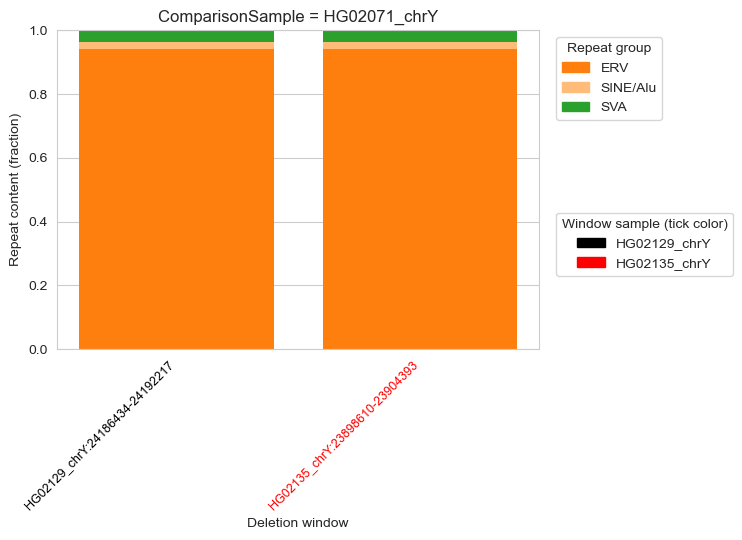

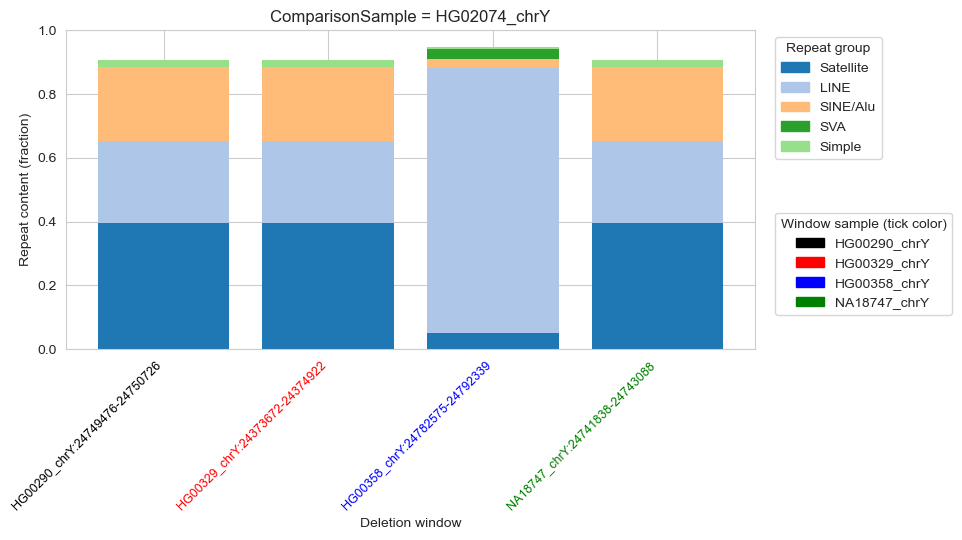

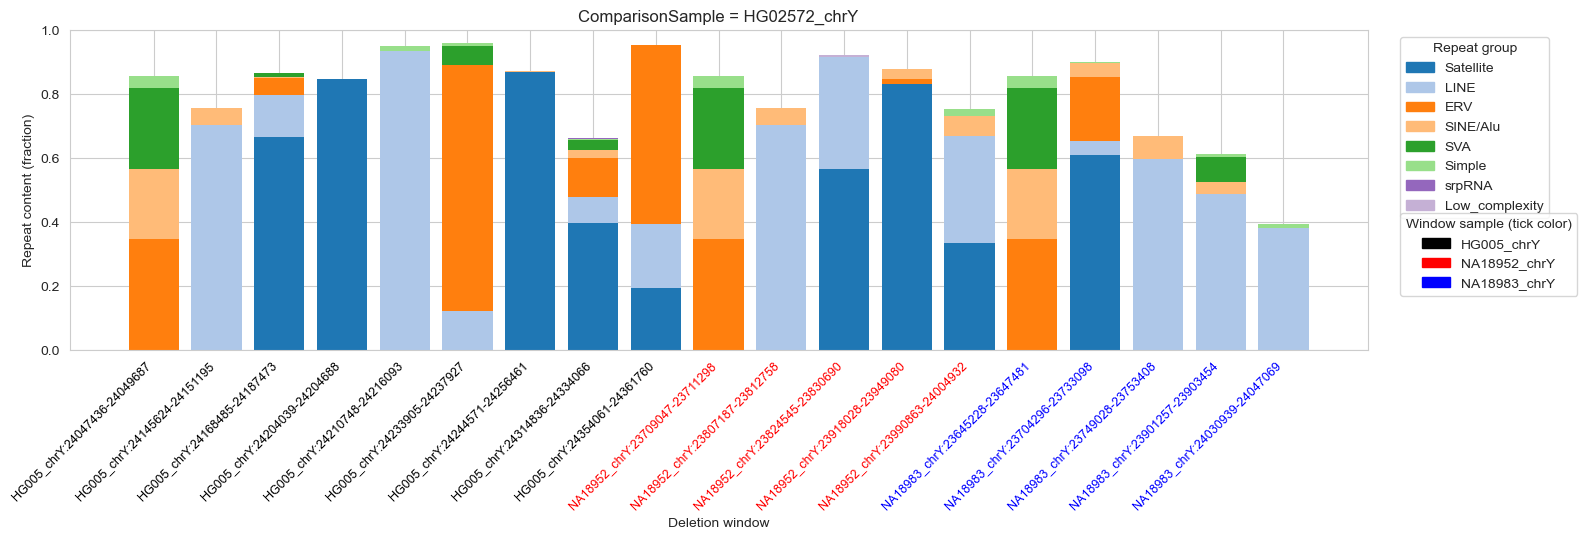

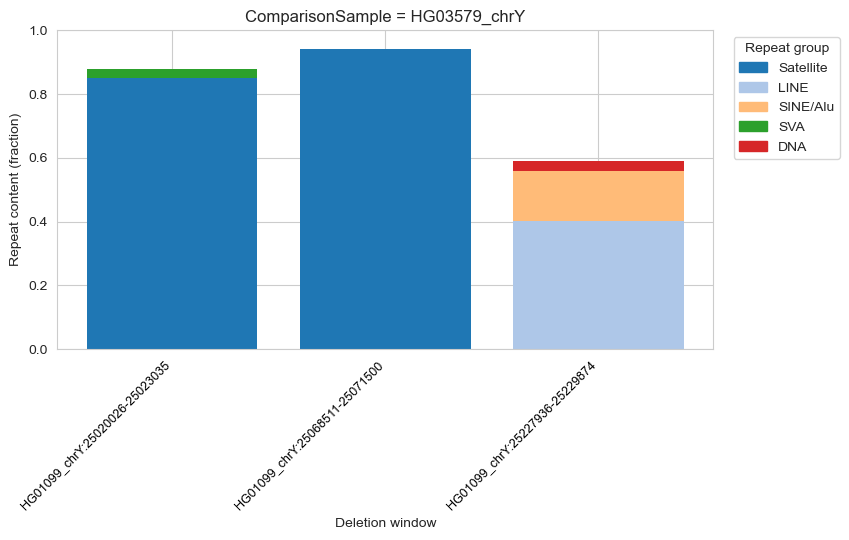

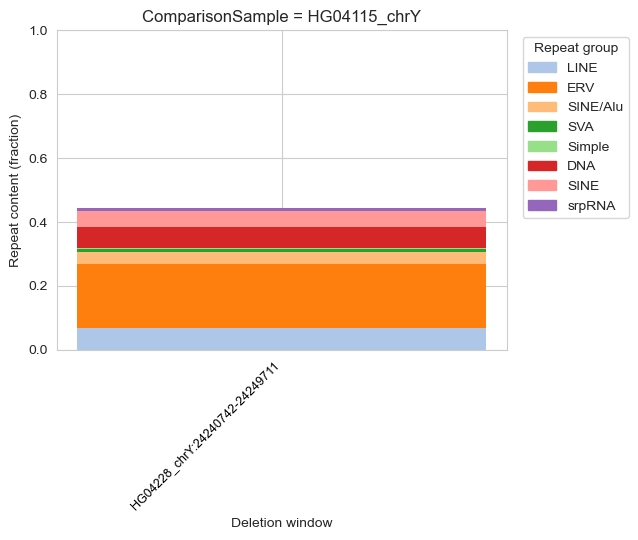

In [14]:
import os
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


df_plot = percentDF.copy()
df_plot["Percentage"] = pd.to_numeric(df_plot["Percentage"], errors="coerce").fillna(0)

def consolidate_repeat(r: str) -> str:
    if pd.isna(r):
        return "Other"
    s = str(r).strip()
    u = s.upper()

    if "ERV" in u:
        return "ERV"
    if "LINE" in u:
        return "LINE"
    if "SINE" in u:
        if "ALU" in u:
            return "SINE/Alu"
        return "SINE"
    if "ALU" in u:
        return "SINE/Alu"
    if "SVA" in u:
        return "SVA"
    if "LTR" in u:
        return "LTR"
    if "DNA" in u:
        return "DNA"
    if "SATELLITE" in u or re.search(r"\bSAT\b", u):
        return "Satellite"
    if "SIMPLE" in u:
        return "Simple"
    if "LOW" in u and "COMPLEX" in u:
        return "Low_complexity"

    if "/" in s:
        return s.split("/", 1)[0]
    return s

df_plot["RepeatGroup"] = df_plot["Repeat"].apply(consolidate_repeat)

df_plot = (df_plot
           .groupby(["ComparisonSample", "Deletion_Window", "RepeatGroup"], as_index=False)["Percentage"]
           .sum())

repeat_order = (
    df_plot.groupby("RepeatGroup")["Percentage"].sum()
    .sort_values(ascending=False)
    .index
)


palette = sns.color_palette("tab20", n_colors=len(repeat_order))
repeat2color = {rep: palette[i] for i, rep in enumerate(repeat_order)}

if "Other" in repeat2color:
    repeat2color["Other"] = (0.7, 0.7, 0.7)

def parse_window(w: str):
    """Expects: sample_chrY:start-end -> (sample_chrY, start, end)"""
    w = str(w)
    if ":" in w:
        sample_part, coords = w.split(":", 1)
    else:
        return (w, 10**18, 10**18)

    m = re.match(r"(\d+)-(\d+)", coords)
    if m:
        start = int(m.group(1))
        end = int(m.group(2))
    else:
        start, end = 10**18, 10**18
    return (sample_part, start, end)

def sort_key_window(w: str):
    sample_part, start, end = parse_window(w)
    return (sample_part, start, end)

def figure_width(n_bars: int) -> float:
    w = 6.5 + 1.05 * max(0, n_bars - 1)
    return min(max(w, 6.5), 16.0)

def sample_color_map(samples):
    palette2 = ["black", "red", "blue", "green", "purple", "orange", "brown", "magenta", "teal"]
    return {s: palette2[i % len(palette2)] for i, s in enumerate(samples)}

sns.set_style("whitegrid")

outdir = "/repeat_stacks"
if outdir is not None:
    os.makedirs(outdir, exist_ok=True)

for comp_sample, sub in df_plot.groupby("ComparisonSample", sort=True):

    wide = (sub.pivot_table(index="Deletion_Window",
                            columns="RepeatGroup",
                            values="Percentage",
                            aggfunc="sum")
              .reindex(columns=repeat_order)
              .fillna(0))

    wide = wide.loc[sorted(wide.index, key=sort_key_window)]
    if wide.shape[0] == 0:
        continue

    window_samples = [parse_window(w)[0] for w in wide.index]
    unique_window_samples = []
    seen = set()
    for s in window_samples:
        if s not in seen:
            unique_window_samples.append(s)
            seen.add(s)
    tick_color = sample_color_map(unique_window_samples)

    n_windows = len(wide)
    fig, ax = plt.subplots(figsize=(figure_width(n_windows), 5.5))

    x = list(range(n_windows))
    bottom = None

    cols_present = [c for c in wide.columns if wide[c].sum() > 0]

    repeat_handles = []
    for rep in cols_present:
        vals = wide[rep].to_numpy()
        ax.bar(x, vals, bottom=bottom, linewidth=0, color=repeat2color.get(rep, None))
        bottom = vals if bottom is None else bottom + vals
        repeat_handles.append(mpatches.Patch(color=repeat2color.get(rep, (0.5, 0.5, 0.5)), label=rep))

    ax.set_xticks(x)
    ax.set_xticklabels(wide.index, rotation=45, ha="right", fontsize=9)
    for lbl, w in zip(ax.get_xticklabels(), wide.index):
        s = parse_window(w)[0]
        lbl.set_color(tick_color.get(s, "black"))

    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Repeat content (fraction)")
    ax.set_xlabel("Deletion window")
    ax.set_title(f"ComparisonSample = {comp_sample}")

    repeat_leg = ax.legend(handles=repeat_handles, title="Repeat group",
                           bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

    if len(unique_window_samples) > 1:
        tick_handles = [mpatches.Patch(color=tick_color[s], label=s) for s in unique_window_samples]
        tick_leg = ax.legend(handles=tick_handles, title="Window sample (tick color)",
                             bbox_to_anchor=(1.02, 0.45), loc="upper left", frameon=True)
        ax.add_artist(repeat_leg)

    fig.tight_layout()

    if outdir is not None:
        safe = str(comp_sample).replace("/", "_")
        #fig.savefig(os.path.join(outdir, f"stacked_repeats_{safe}.jpeg"),
        #            dpi=300, bbox_inches="tight")
        #fig.savefig(os.path.join(outdir, f"stacked_repeats_{safe}.pdf"),
        #           bbox_inches="tight")

    plt.show()


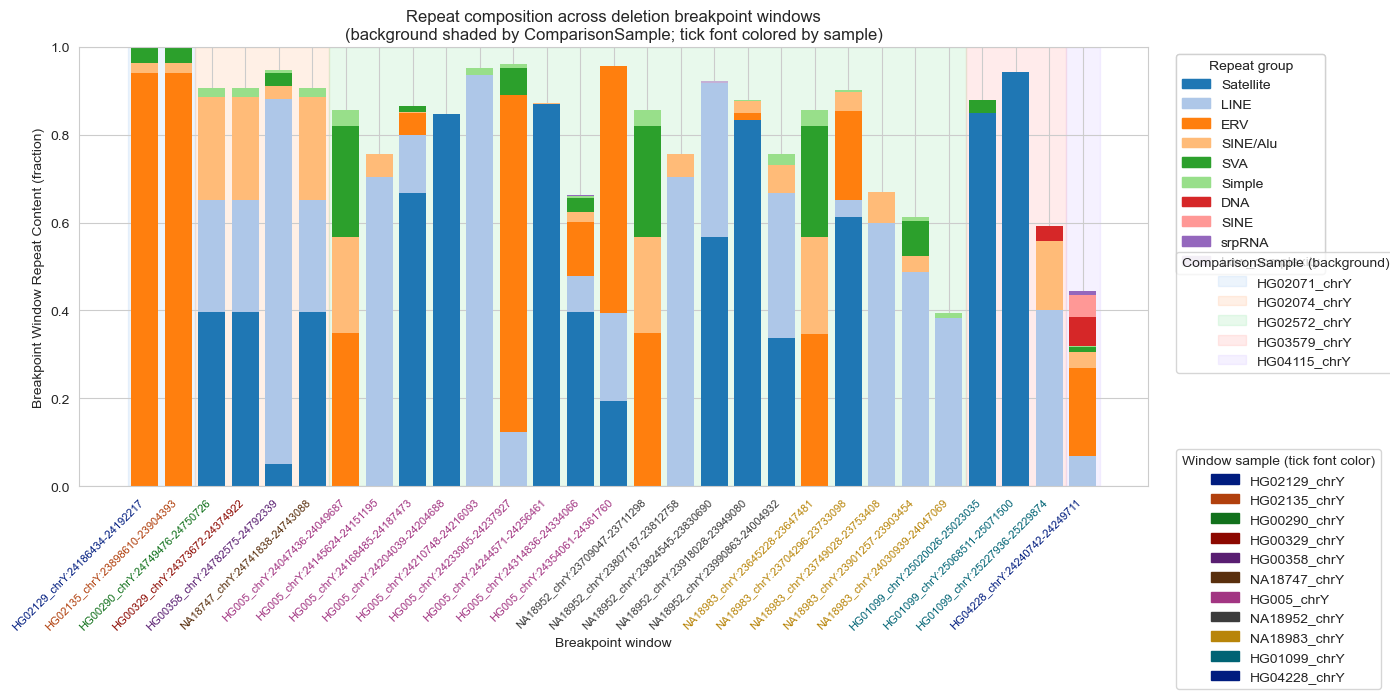

In [15]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_plot = percentDF.copy()
df_plot["Percentage"] = pd.to_numeric(df_plot["Percentage"], errors="coerce").fillna(0)

def consolidate_repeat(r: str) -> str:
    if pd.isna(r):
        return "Other"
    s = str(r).strip()
    u = s.upper()

    if "ERV" in u:
        return "ERV"
    if "LINE" in u:
        return "LINE"
    if "SINE" in u:
        if "ALU" in u:
            return "SINE/Alu"
        return "SINE"
    if "ALU" in u:
        return "SINE/Alu"
    if "SVA" in u:
        return "SVA"
    if "LTR" in u:
        return "LTR"
    if "DNA" in u:
        return "DNA"
    if "SATELLITE" in u or re.search(r"\bSAT\b", u):
        return "Satellite"
    if "SIMPLE" in u:
        return "Simple"
    if "LOW" in u and "COMPLEX" in u:
        return "Low_complexity"

    if "/" in s:
        return s.split("/", 1)[0]
    return s

df_plot["RepeatGroup"] = df_plot["Repeat"].apply(consolidate_repeat)

df_plot = (df_plot
           .groupby(["ComparisonSample", "Deletion_Window", "RepeatGroup"], as_index=False)["Percentage"]
           .sum())

repeat_order = (
    df_plot.groupby("RepeatGroup")["Percentage"].sum()
    .sort_values(ascending=False)
    .index
)
repeat_palette = sns.color_palette("tab20", n_colors=len(repeat_order))
repeat2color = {rep: repeat_palette[i] for i, rep in enumerate(repeat_order)}
if "Other" in repeat2color:
    repeat2color["Other"] = (0.7, 0.7, 0.7)

def parse_window(w: str):
    """sample_chrY:start-end -> (sample_chrY, start, end)"""
    w = str(w)
    if ":" in w:
        sample_part, coords = w.split(":", 1)
    else:
        return (w, 10**18, 10**18)
    m = re.match(r"(\d+)-(\d+)", coords)
    if m:
        start = int(m.group(1))
        end = int(m.group(2))
    else:
        start, end = 10**18, 10**18
    return (sample_part, start, end)

def sort_key_window(w: str):
    sample_part, start, end = parse_window(w)
    return (sample_part, start, end)

wide = (df_plot.pivot_table(index=["ComparisonSample", "Deletion_Window"],
                            columns="RepeatGroup",
                            values="Percentage",
                            aggfunc="sum")
              .reindex(columns=repeat_order)
              .fillna(0))

wide = wide.reset_index()
wide["__sort_sample"] = wide["Deletion_Window"].apply(lambda x: sort_key_window(x)[0])
wide["__sort_start"]  = wide["Deletion_Window"].apply(lambda x: sort_key_window(x)[1])
wide["__sort_end"]    = wide["Deletion_Window"].apply(lambda x: sort_key_window(x)[2])

wide = wide.sort_values(["ComparisonSample", "__sort_sample", "__sort_start", "__sort_end"]).drop(
    columns=["__sort_sample", "__sort_start", "__sort_end"]
)

x_labels = wide["Deletion_Window"].tolist()
comp_labels = wide["ComparisonSample"].tolist()
sample_labels = [parse_window(w)[0] for w in x_labels]  # sample_chrY for each tick

mat = wide.set_index(["ComparisonSample", "Deletion_Window"])[repeat_order]


bg_palette = sns.color_palette("pastel", n_colors=len(set(comp_labels)))
comp2bg = {c: bg_palette[i] for i, c in enumerate(sorted(set(comp_labels)))}

unique_samples = list(dict.fromkeys(sample_labels))  # preserve first-seen order
sample_palette = sns.color_palette("dark", n_colors=len(unique_samples))
sample2font = {s: sample_palette[i] for i, s in enumerate(unique_samples)}

sns.set_style("whitegrid")

n_bars = mat.shape[0]
fig_w = min(max(14, 0.35 * n_bars), 34)
fig, ax = plt.subplots(figsize=(fig_w, 7))

x = list(range(n_bars))
bottom = None

cols_present = [c for c in mat.columns if mat[c].sum() > 0]
for rep in cols_present:
    vals = mat[rep].to_numpy()
    ax.bar(x, vals, bottom=bottom, linewidth=0, color=repeat2color.get(rep, None))
    bottom = vals if bottom is None else bottom + vals

start = 0
for i in range(1, len(comp_labels) + 1):
    if i == len(comp_labels) or comp_labels[i] != comp_labels[start]:
        end = i - 1
        c = comp_labels[start]
        ax.axvspan(start - 0.5, end + 0.5, color=comp2bg[c], alpha=0.20, zorder=0)
        start = i

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)

for lbl, samp in zip(ax.get_xticklabels(), sample_labels):
    lbl.set_color(sample2font.get(samp, "black"))

ax.set_ylim(0, 1.0)
ax.set_ylabel("Breakpoint Window Repeat Content (fraction)")
ax.set_xlabel("Breakpoint window")
ax.set_title("Repeat composition across deletion breakpoint windows\n(background shaded by ComparisonSample; tick font colored by sample)")

repeat_handles = [mpatches.Patch(color=repeat2color[rep], label=rep) for rep in cols_present]
leg1 = ax.legend(handles=repeat_handles, title="Repeat group",
                 bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

comp_handles = [mpatches.Patch(color=comp2bg[c], alpha=0.20, label=c) for c in sorted(set(comp_labels))]
leg2 = ax.legend(handles=comp_handles, title="ComparisonSample (background)",
                 bbox_to_anchor=(1.02, 0.55), loc="upper left", frameon=True)
ax.add_artist(leg1)

SHOW_SAMPLE_TICK_LEGEND = True
if SHOW_SAMPLE_TICK_LEGEND:
    samp_handles = [mpatches.Patch(color=sample2font[s], label=s) for s in unique_samples]
    leg3 = ax.legend(handles=samp_handles, title="Window sample (tick font color)",
                     bbox_to_anchor=(1.02, 0.10), loc="upper left", frameon=True)
    ax.add_artist(leg1)
    ax.add_artist(leg2)

fig.tight_layout()
#fig.savefig(os.path.join(outdir, f"stacked_repeats_combined_{safe}.pdf"),
#                    bbox_inches="tight")
plt.show()


In [17]:
repeat2color

{'Satellite': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'LINE': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'ERV': (1.0, 0.4980392156862745, 0.054901960784313725),
 'SINE/Alu': (1.0, 0.7333333333333333, 0.47058823529411764),
 'SVA': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'Simple': (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 'DNA': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'SINE': (1.0, 0.596078431372549, 0.5882352941176471),
 'srpRNA': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'Low_complexity': (0.7725490196078432,
  0.6901960784313725,
  0.8352941176470589)}

In [16]:
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

winDF = percentDF.copy()

winDF["basepair"] = pd.to_numeric(winDF["basepair"], errors="coerce")
winDF["windowLength"] = pd.to_numeric(winDF["windowLength"], errors="coerce")
winDF = winDF.dropna(subset=["Deletion_Window", "Repeat", "basepair", "windowLength"]).copy()

bg_rows = []
for win, d in windowBlockDict.items():
    if not isinstance(d, dict) or len(d) == 0:
        continue

    bg_len = d.get("BlockMinusWindowSize", None)
    if bg_len is None:

        bg_len = d.get("BlockSize", None)

    for rep, bp in d.items():
        if rep in {"BlockSize", "WindowSizeInBlock", "BlockMinusWindowSize"}:
            continue

        bg_rows.append({
            "Deletion_Window": win,
            "Repeat": rep,
            "bg_basepair": bp,
            "bg_length": bg_len
        })

bgDF = pd.DataFrame(bg_rows)

bgLenDF = pd.DataFrame([
    {"Deletion_Window": win, "bg_length": d.get("BlockMinusWindowSize", np.nan)}
    for win, d in windowBlockDict.items()
    if isinstance(d, dict)
])

testDF = (winDF
          .merge(bgDF, on=["Deletion_Window", "Repeat"], how="left")
          .merge(bgLenDF, on="Deletion_Window", how="left", suffixes=("", "_lenfix")))


testDF["bg_basepair"] = testDF["bg_basepair"].fillna(0)

testDF["bg_length"] = testDF["bg_length"].fillna(testDF["bg_length_lenfix"])
testDF = testDF.drop(columns=["bg_length_lenfix"])

testDF["bg_length"] = pd.to_numeric(testDF["bg_length"], errors="coerce")
testDF = testDF.dropna(subset=["bg_length"]).copy()
testDF = testDF[(testDF["bg_length"] > 0) & (testDF["windowLength"] > 0)].copy()

results = []

for row in testDF.itertuples(index=False):
    W_R = int(round(row.basepair))
    W_total = int(round(row.windowLength))
    W_notR = max(0, W_total - W_R)

    B_R = int(round(row.bg_basepair))
    B_total = int(round(row.bg_length))
    B_notR = max(0, B_total - B_R)

    if W_R < 0 or W_notR < 0 or B_R < 0 or B_notR < 0:
        continue

    table = np.array([
        [W_R, W_notR],
        [B_R, B_notR]
    ])


    oddsratio, pval = fisher_exact(table, alternative="greater")

    window_frac = W_R / W_total if W_total else np.nan
    bg_frac = B_R / B_total if B_total else np.nan

    if B_R == 0:
        fold = np.inf if W_R > 0 else 1.0
    else:
        fold = window_frac / bg_frac

    results.append({
        "Deletion_Window": row.Deletion_Window,
        "ComparisonSample": row.ComparisonSample,
        "Repeat": row.Repeat,
        "window_bp": W_R,
        "window_len": W_total,
        "bg_bp": B_R,
        "bg_len": B_total,
        "window_fraction": window_frac,
        "bg_fraction": bg_frac,
        "fold_enrichment": fold,
        "oddsratio": oddsratio,
        "pvalue": pval
    })

resDF = pd.DataFrame(results)

resDF["padj"] = multipletests(resDF["pvalue"], method="fdr_bh")[1]

resDF = resDF.sort_values(["padj", "fold_enrichment"], ascending=[True, False])

In [20]:
sigDF = resDF[(resDF['padj']<0.05) & (resDF['window_fraction']>0.10)].copy()
pooled = (
    sigDF.groupby("Repeat", as_index=False)
    .agg(
        mean_fold=("fold_enrichment","mean"),
        median_fold=("fold_enrichment","median"),
        n_sig=("padj", lambda x: (x < 0.05).sum()),
        n_tests=("padj","size")
    )
    .sort_values(by=['median_fold'], ascending=False)
)
pooled

,Repeat,mean_fold,median_fold,n_sig,n_tests
4,LTR/ERVL-MaLR,102.227732,102.240094,3,3
5,Retroposon/SVA,20.470987,19.967720,3,3
6,SINE/Alu,6.846902,6.991644,7,7
3,LTR/ERVK,8.419233,4.727911,4,4
0,LINE/CR1,4.014229,4.014229,1,1
2,LTR/ERV1,5.257975,2.313175,7,7
7,Satellite,34.137198,2.253764,10,10
1,LINE/L1,2.422648,1.748931,14,14


In [23]:
import re
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

def collapse_repeat(r: str) -> str:
    if pd.isna(r):
        return "Other"
    s = str(r).strip()
    u = s.upper()

    if "ERV" in u:
        return "ERV"
    if "LINE" in u:
        return "LINE"
    if "SINE" in u:
        if "ALU" in u:
            return "SINE/Alu"
        return "SINE"
    if "ALU" in u:
        return "SINE/Alu"
    if "SVA" in u:
        return "SVA"
    if "LTR" in u:
        return "LTR"
    if "DNA" in u:
        return "DNA"
    if "SATELLITE" in u or re.search(r"\bSAT\b", u):
        return "Satellite"
    if "SIMPLE" in u:
        return "Simple"
    if "LOW" in u and "COMPLEX" in u:
        return "Low_complexity"

    if "/" in s:
        return s.split("/", 1)[0]
    return s


winDF = percentDF.copy()
winDF["basepair"] = pd.to_numeric(winDF["basepair"], errors="coerce")
winDF["windowLength"] = pd.to_numeric(winDF["windowLength"], errors="coerce")
winDF = winDF.dropna(subset=["Deletion_Window", "Repeat", "basepair", "windowLength"]).copy()

winDF["RepeatGroup"] = winDF["Repeat"].apply(collapse_repeat)
winAgg = (winDF
          .groupby(["Deletion_Window", "ComparisonSample", "RepeatGroup"], as_index=False)
          .agg(basepair=("basepair", "sum"),
               windowLength=("windowLength", "first")))


bg_rows = []
bg_len_rows = []

for win, d in windowBlockDict.items():
    if not isinstance(d, dict) or len(d) == 0:
        continue

    bg_len = d.get("BlockMinusWindowSize", None)
    if bg_len is None:
        bg_len = d.get("BlockSize", None)

    bg_len_rows.append({"Deletion_Window": win, "bg_length": bg_len})
    tmp = {}
    for rep, bp in d.items():
        if rep in {"BlockSize", "WindowSizeInBlock", "BlockMinusWindowSize"}:
            continue
        repg = collapse_repeat(rep)
        tmp[repg] = tmp.get(repg, 0) + int(bp)

    for repg, bp_sum in tmp.items():
        bg_rows.append({
            "Deletion_Window": win,
            "RepeatGroup": repg,
            "bg_basepair": int(bp_sum),
            "bg_length": bg_len
        })

bgDF = pd.DataFrame(bg_rows)
bgLenDF = pd.DataFrame(bg_len_rows)

testDF = (winAgg
          .merge(bgDF, on=["Deletion_Window", "RepeatGroup"], how="left")
          .merge(bgLenDF, on="Deletion_Window", how="left", suffixes=("", "_lenfix")))

testDF["bg_basepair"] = testDF["bg_basepair"].fillna(0)

testDF["bg_length"] = testDF["bg_length"].fillna(testDF["bg_length_lenfix"])
testDF = testDF.drop(columns=["bg_length_lenfix"])

testDF["bg_length"] = pd.to_numeric(testDF["bg_length"], errors="coerce")
testDF = testDF.dropna(subset=["bg_length"]).copy()
testDF = testDF[(testDF["bg_length"] > 0) & (testDF["windowLength"] > 0)].copy()

results = []

for row in testDF.itertuples(index=False):
    W_R = int(round(row.basepair))
    W_total = int(round(row.windowLength))
    W_notR = max(0, W_total - W_R)

    B_R = int(round(row.bg_basepair))
    B_total = int(round(row.bg_length))
    B_notR = max(0, B_total - B_R)

    if W_R < 0 or W_notR < 0 or B_R < 0 or B_notR < 0:
        continue

    table = np.array([[W_R, W_notR],
                      [B_R, B_notR]])

    oddsratio, pval = fisher_exact(table, alternative="greater")

    window_frac = W_R / W_total if W_total else np.nan
    bg_frac = B_R / B_total if B_total else np.nan

    if B_R == 0:
        fold = np.inf if W_R > 0 else 1.0
    else:
        fold = window_frac / bg_frac

    results.append({
        "Deletion_Window": row.Deletion_Window,
        "ComparisonSample": row.ComparisonSample,
        "RepeatGroup": row.RepeatGroup,
        "window_bp": W_R,
        "window_len": W_total,
        "bg_bp": B_R,
        "bg_len": B_total,
        "window_fraction": window_frac,
        "bg_fraction": bg_frac,
        "fold_enrichment": fold,
        "oddsratio": oddsratio,
        "pvalue": pval
    })

resDF_collapsed = pd.DataFrame(results)


resDF_collapsed["padj"] = multipletests(resDF_collapsed["pvalue"], method="fdr_bh")[1]
resDF_collapsed = resDF_collapsed.sort_values(["padj", "fold_enrichment"], ascending=[True, False])
resDF_collapsed.head(30)

,Deletion_Window,ComparisonSample,RepeatGroup,window_bp,window_len,bg_bp,bg_len,window_fraction,bg_fraction,fold_enrichment,oddsratio,pvalue,padj
43,HG005_chrY:24354061-24361760,HG02572_chrY,Satellite,1501,7700,88,145956,0.194935,0.000603,323.317527,401.362148,0.000000e+00,0.000000e+00
87,NA18983_chrY:23645228-23647481,HG02572_chrY,SVA,570,2254,3568,304938,0.252884,0.011701,21.612631,28.589591,0.000000e+00,0.000000e+00
70,NA18952_chrY:23709047-23711298,HG02572_chrY,SVA,570,2252,3864,304831,0.253108,0.012676,19.967720,26.395545,0.000000e+00,0.000000e+00
15,HG005_chrY:24047436-24049687,HG02572_chrY,SVA,570,2252,3891,304884,0.253108,0.012762,19.832610,26.214648,0.000000e+00,0.000000e+00
53,HG02135_chrY:23898610-23904393,HG02071_chrY,ERV,5444,5784,40775,301309,0.941217,0.135326,6.955173,102.308010,0.000000e+00,0.000000e+00
50,HG02129_chrY:24186434-24192217,HG02071_chrY,ERV,5444,5784,40789,301314,0.941217,0.135370,6.952902,102.269362,0.000000e+00,0.000000e+00
41,HG005_chrY:24354061-24361760,HG02572_chrY,ERV,4322,7700,13515,145956,0.561299,0.092596,6.061777,12.538094,0.000000e+00,0.000000e+00
28,HG005_chrY:24233905-24237927,HG02572_chrY,ERV,3091,4023,43166,303113,0.768332,0.142409,5.395252,19.972209,0.000000e+00,0.000000e+00
26,HG005_chrY:24210748-24216093,HG02572_chrY,LINE,5003,5346,56248,301790,0.935840,0.186381,5.021105,63.672967,0.000000e+00,0.000000e+00
8,HG00358_chrY:24782575-24792339,HG02074_chrY,LINE,8107,9765,53112,297388,0.830210,0.178595,4.648563,22.488671,0.000000e+00,0.000000e+00


In [30]:
resDF_collapsed[(resDF_collapsed['Deletion_Window']=='HG00358_chrY:24782575-24792339') & (resDF_collapsed['padj']<=0.05)]

,Deletion_Window,ComparisonSample,RepeatGroup,window_bp,window_len,bg_bp,bg_len,window_fraction,bg_fraction,fold_enrichment,oddsratio,pvalue,padj
8,HG00358_chrY:24782575-24792339,HG02074_chrY,LINE,8107,9765,53112,297388,0.830210,0.178595,4.648563,22.488671,0.000000e+00,0.000000e+00
10,HG00358_chrY:24782575-24792339,HG02074_chrY,SVA,286,9765,4367,297388,0.029288,0.014685,1.994500,2.024506,2.444044e-25,4.703633e-25
12,HG00358_chrY:24782575-24792339,HG02074_chrY,Simple,68,9765,1474,297388,0.006964,0.004956,1.404956,1.407795,5.103638e-03,7.655457e-03


In [25]:
sigDF = resDF_collapsed[(resDF_collapsed['padj']<0.05) & (resDF_collapsed['window_fraction']>0.10)].copy()
pooled = (
    sigDF.groupby("RepeatGroup", as_index=False)
    .agg(
        mean_fold=("fold_enrichment","mean"),
        median_fold=("fold_enrichment","median"),
        n_sig=("padj", lambda x: (x < 0.05).sum()),
        n_tests=("padj","size")
    )
    .sort_values(by=['median_fold'], ascending=False)
)
pooled

,RepeatGroup,mean_fold,median_fold,n_sig,n_tests
3,SVA,20.470987,19.967720,3,3
2,SINE/Alu,6.846902,6.991644,7,7
0,ERV,3.925467,2.331793,9,9
4,Satellite,34.137198,2.253764,10,10
1,LINE,2.537645,1.782170,13,13
